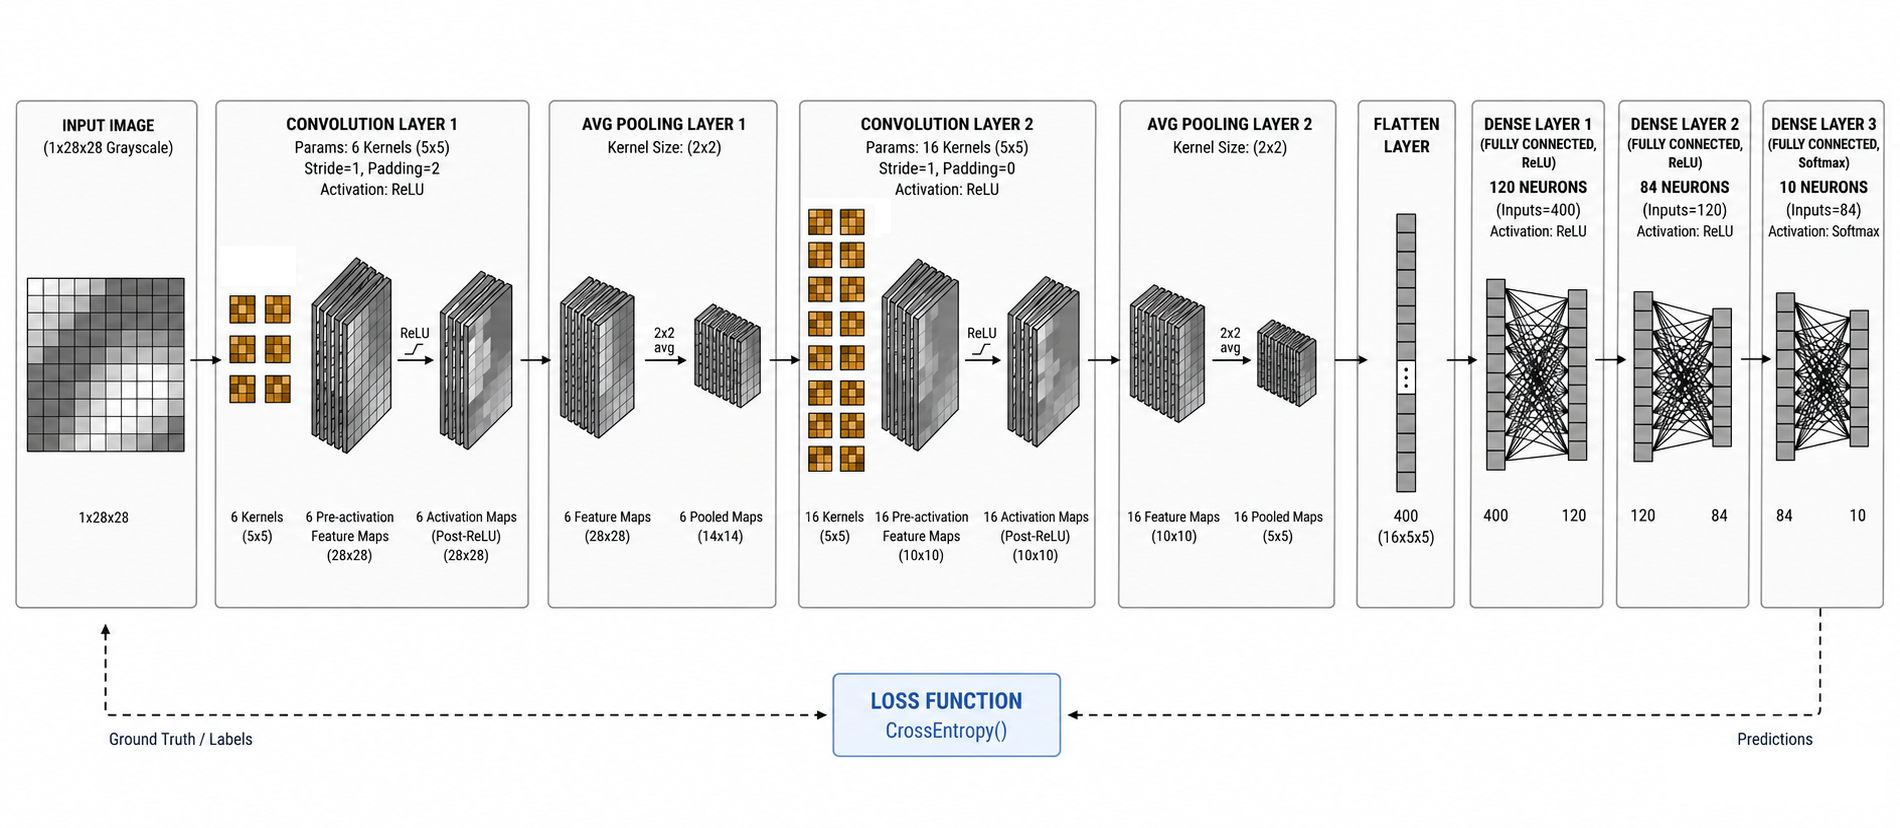

In [23]:
#from google.colab import drive
#drive.mount('/content/drive') #mounting google drive

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
#import sys
# Definir la ruta de tu proyecto
#repo_path = '/content/drive/MyDrive/Colab Notebooks'
#if repo_path not in sys.path:
#    sys.path.append(repo_path)

#!pip install idx2numpy

In [22]:
import time
import importlib
import numpy as np
import sys
import urllib.request
import matplotlib.pyplot as plt
sys.path.append('../')
import idx2numpy # pip install idx2numpy
import deep_learning
import deep_learning.model
import deep_learning.utils
import idx2numpy # pip install idx2numpy
import gzip
import shutil
from pathlib import Path
#importlib.reload(deep_learning.model)
#importlib.reload(deep_learning.utils)
from deep_learning.utils import train_test_split,to_one_hot,plot_learning_curve,plot_neuron_heatmap
from deep_learning.model import SequentialNetwork,Dense,Softmax,CrossEntropy,ReLU,Convolution2D,Flatten # import my implmentation

In [7]:
# The MNIST database of handwritten digits has a training set of 60,000 examples, and a test set of 10,000 examples. Image Dimensions: 28x28 pixels, totaling 784 pixels per image. Grayscale
def read_mnist_database(keyname):
    dir_name = './mnist/'
    Path(dir_name).mkdir(exist_ok=True)
    files = {
        'train_images': 'train-images-idx3-ubyte.gz',
        'train_labels': 'train-labels-idx1-ubyte.gz',
        'test_images':  't10k-images-idx3-ubyte.gz',
        'test_labels':  't10k-labels-idx1-ubyte.gz',
    }
    base_url = 'https://storage.googleapis.com/cvdf-datasets/mnist/'
    urllib.request.urlretrieve(base_url+files[keyname],dir_name+files[keyname])  # download
    with gzip.open(dir_name+files[keyname], 'rb') as f_in: #as bytes
        out_file_name=files[keyname].split('.')[0]
        with open(dir_name+out_file_name, 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)
    return idx2numpy.convert_from_file(dir_name+out_file_name)

train_images = read_mnist_database('train_images') # (60000, 28, 28)
train_labels = read_mnist_database('train_labels') # (60000,)
test_images = read_mnist_database('test_images') # (10000, 28, 28)
test_labels = read_mnist_database('test_labels') # (10000,)

In [8]:
SEED = 24
X_train=train_images
X_test=test_images
X_train=X_train.reshape(X_train.shape[0], 1, X_train.shape[1], X_train.shape[2]) # adding channel dimension
X_test=X_test.reshape(X_test.shape[0], 1, X_test.shape[1], X_test.shape[2]) # adding channel dimension

In [9]:
# normalization
X_max = 255
X_train = (X_train) / (X_max)
X_test = (X_test ) / (X_max)


In [10]:
y_train_one_hot=to_one_hot(train_labels,10)
y_test_one_hot=to_one_hot(test_labels,10)

In [11]:
subgroup=10000
X_train = X_train[0:subgroup] # shape (1,28,28)
y_train_one_hot = y_train_one_hot[0:subgroup]
train_labels=train_labels[0:subgroup]


In [15]:
importlib.reload(deep_learning.model)
importlib.reload(deep_learning.utils)
from deep_learning.utils import train_test_split,to_one_hot,plot_learning_curve,plot_neuron_heatmap
from deep_learning.model import SequentialNetwork,Dense,Softmax,CrossEntropy,ReLU,Convolution2D,AVGPooling,Flatten # import my implmentation
EPOCHS = 20
LR = 0.08

# Lenet-5
model = SequentialNetwork(layers=[
    Convolution2D(kernel_size=(5,5),n_kernels=6, input_shape=(1,28,28), stride=1, padding=2, activation_function=ReLU(), lr=LR, seed=SEED,fast=True),
    AVGPooling(kernel_size=(2,2)),
    Convolution2D(kernel_size=(5,5),n_kernels=16, input_shape=(6, 14, 14), stride=1, padding=0, activation_function=ReLU(), lr=LR, seed=SEED,fast=True),
    AVGPooling(kernel_size=(2,2)),
    Flatten(),
    Dense(inputs=400, neurons=120, activation_function=ReLU(), lr=LR, seed=SEED),
    Dense(inputs=120, neurons=84, activation_function=ReLU(), lr=LR, seed=SEED),
    Dense(inputs=84, neurons=10, activation_function=Softmax(), lr=LR, seed=SEED)
], loss_function=CrossEntropy())


Convolutional 2D layer with: 156 trainable parameters, 4704 neurons, 122304 connections, Input: (1, 28, 28),  Output: (6, 28, 28)
AVGPooling layer with kernel size: 2 x 2
Convolutional 2D layer with: 2416 trainable parameters, 1600 neurons, 241600 connections, Input: (6, 14, 14),  Output: (16, 10, 10)
AVGPooling layer with kernel size: 2 x 2
Flatten layer
Dense layer with: 48120 trainable parameters, 120 neurons, 48120 connections
Dense layer with: 10164 trainable parameters, 84 neurons, 10164 connections
Dense layer with: 850 trainable parameters, 10 neurons, 850 connections


In [16]:
start = time.perf_counter()
BATCH_SIZE=500#len(X_train)
n_batches = len(X_train) / BATCH_SIZE
for epoch in range(EPOCHS):
    epoch_loss = model._train_one_epoch(X_train,y_train_one_hot, BATCH_SIZE,True) #
    #train and test evaluation
    #train_preds = np.argmax(model.predict(X_train), axis=1)
    #test_preds  = np.argmax(model.predict(X_test), axis=1)
    #train_acc   = np.mean(train_preds == train_labels)
    #test_acc    = np.mean(test_preds  == test_labels)

    #print(f"Epoch: {epoch+1} | Loss: {epoch_loss}  Loss/batch: {epoch_loss / n_batches} | Train acc: {train_acc:.2%} | Test acc: {test_acc:.2%}") #first loss/n_batches should be  2.3 — tha is log(10)
    print(f"Epoch: {epoch+1} | Loss: {epoch_loss}  Loss/batch: {epoch_loss / n_batches} ")

loss=model.losses
end = time.perf_counter()
print(f"Elapsed time: {end - start} seconds")

Epoch: 1 | Loss: 39.942369361560814  Loss/batch: 1.9971184680780407 
Epoch: 2 | Loss: 21.8167736036778  Loss/batch: 1.0908386801838899 
Epoch: 3 | Loss: 12.194796071105152  Loss/batch: 0.6097398035552576 
Epoch: 4 | Loss: 9.767645638236646  Loss/batch: 0.4883822819118323 
Epoch: 5 | Loss: 6.810660243490715  Loss/batch: 0.34053301217453574 
Epoch: 6 | Loss: 6.9339033534103125  Loss/batch: 0.3466951676705156 
Epoch: 7 | Loss: 6.340292092470186  Loss/batch: 0.3170146046235093 
Epoch: 8 | Loss: 5.023254464462773  Loss/batch: 0.25116272322313865 
Epoch: 9 | Loss: 4.96569482267532  Loss/batch: 0.248284741133766 
Epoch: 10 | Loss: 4.500361420047356  Loss/batch: 0.2250180710023678 
Epoch: 11 | Loss: 4.070789959919566  Loss/batch: 0.20353949799597829 
Epoch: 12 | Loss: 3.8471590881668924  Loss/batch: 0.19235795440834463 
Epoch: 13 | Loss: 3.664796832201583  Loss/batch: 0.18323984161007917 
Epoch: 14 | Loss: 3.4829123874948182  Loss/batch: 0.1741456193747409 
Epoch: 15 | Loss: 3.5314735958355805

In [17]:
pred=model.predict(X_train)

In [18]:
test_preds  =np.argmax(pred, axis=1)

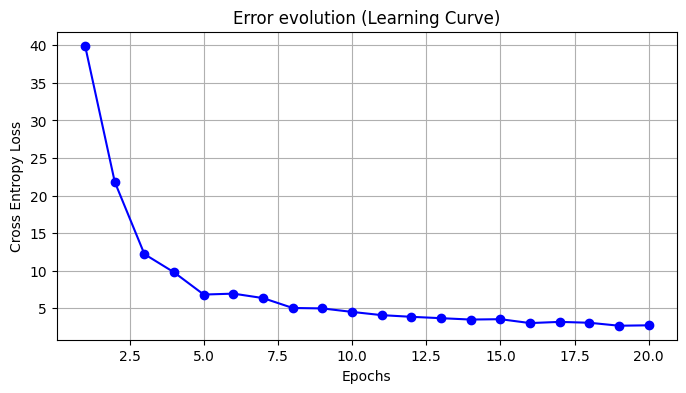

In [19]:
plot_learning_curve(loss, ylabel='Cross Entropy Loss')

In [20]:
probs = model.predict(X_test)
preds=np.argmax(probs,axis=1)

In [21]:
accuracy = np.mean(preds == test_labels)
print(f"Accuracy: {accuracy:.2%}")

Accuracy: 95.39%
